In [12]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch

What was the global change to the isoform landscape across a cohort of 96 rare disease samples
-

Differential Transcript Usage
-



In [7]:
meta = pd.read_csv("applied_depletion_gregor_n100/gencode.v49.metadata.HGNC", sep="\t", header=None)
meta.columns = ["Transcript", "Gene name", "HGNC"]
meta['Transcript stable ID'] = meta['Transcript'].str.split('.').str[0]
meta.set_index('Transcript stable ID', inplace=True)
meta = meta[~meta.index.duplicated(keep='first')]
meta = meta['Gene name'].copy()
meta

Transcript stable ID
ENST00000511072       PRDM16
ENST00000607632       PRDM16
ENST00000378391       PRDM16
ENST00000514189       PRDM16
ENST00000270722       PRDM16
                     ...    
ENST00000710671      CCDC120
ENST00000710672      CCDC120
ENST00000400754        MAFIP
ENST00000611446    RNA5-8SN5
ENST00000616292    RNA5-8SN4
Name: Gene name, Length: 412781, dtype: object

In [8]:
data = pd.read_csv("applied_depletion_gregor_n100/rsem/satuRn_DTU_transcripts_D_vs_WM_with_deltaUsage.csv")
data['significant'] = np.where(data['padj'] < 0.05, 'significant', 'not significant')
data['Transcript stable ID'] = data['isoform_id'].str.split('.').str[0]  
data['Gene name'] = data['Transcript stable ID'].map(meta)
data['Gene name'] = data['Gene name'].fillna(data['isoform_id'])
data['-log10(pvalue)'] = -np.log10(data['pval'])
data['-log10(pvalue)'] = data['-log10(pvalue)'].replace([np.inf, -np.inf], 300)
data

,isoform_id,gene_id,estimates,se,df,t,pval,regular_FDR,empirical_pval,empirical_FDR,padj,mean_usage_WM,mean_usage_D,delta_usage,significant,Transcript stable ID,Gene name,-log10(pvalue)
0,ENST00000565324.5,ENSG00000157106.18,9.580999,3.365050e-02,97.344773,2.847208e+02,5.402505e-144,2.161002e-141,NaN,NaN,4.039885e-139,0.000000,0.424409,0.424409,significant,ENST00000565324,SMG1,1.432674e+02
1,ENST00000617275.5,ENSG00000169499.15,-3.247169,1.567342e-02,97.344773,-2.071768e+02,1.417355e-130,5.669419e-128,NaN,NaN,5.299348e-126,0.924505,0.324869,-0.599636,significant,ENST00000617275,PLEKHA2,1.298485e+02
2,ENST00000469717.5,ENSG00000143549.22,-1.862086,1.036345e-02,97.344773,-1.796782e+02,1.432989e-124,5.731958e-122,NaN,NaN,3.571870e-120,0.084088,0.014045,-0.070043,significant,ENST00000469717,TPM3,1.238438e+02
3,ENST00000489372.4,ENSG00000171988.20,0.950663,5.374460e-03,97.344773,1.768854e+02,6.554355e-124,2.621742e-121,NaN,NaN,1.225304e-119,0.096922,0.217062,0.120140,significant,ENST00000489372,JMJD1C,1.231835e+02
4,ENST00000704008.1,ENSG00000165119.23,-6.954839,4.030869e-02,97.344773,-1.725394e+02,7.326376e-123,2.930550e-120,NaN,NaN,1.095703e-118,0.087511,0.000000,-0.087511,significant,ENST00000704008,HNRNPK,1.221351e+02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74773,ENST00000623471.1,ENSG00000276255.2,-0.619571,5.183515e+06,97.344773,-1.195272e-07,9.999999e-01,9.999999e-01,NaN,NaN,1.000000e+00,0.336978,0.271572,-0.065406,not significant,ENST00000623471,LINC02809,4.131195e-08
74774,ENST00000593495.4,ENSG00000286019.3,-0.145356,3.725687e+06,97.344773,-3.901454e-08,1.000000e+00,1.000000e+00,NaN,NaN,1.000000e+00,0.426789,0.421970,-0.004819,not significant,ENST00000593495,NOTCH2NLB,1.348452e-08
74775,ENST00000850899.1,ENSG00000286019.3,0.145356,3.725687e+06,97.344773,3.901454e-08,1.000000e+00,1.000000e+00,NaN,NaN,1.000000e+00,0.573211,0.578030,0.004819,not significant,ENST00000850899,NOTCH2NLB,1.348452e-08
74776,ENST00000637084.1,ENSG00000287725.2,0.000000,1.218361e-02,94.344773,0.000000e+00,1.000000e+00,1.000000e+00,NaN,NaN,1.000000e+00,0.484375,0.500000,0.015625,not significant,ENST00000637084,ENST00000637084.1,-0.000000e+00


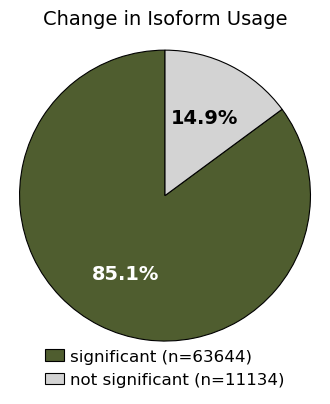

In [9]:
order = ['significant', 'not significant']
colors_map = {'significant': '#4F5D2F', 'not significant': 'lightgrey'}

counts = data['significant'].value_counts()
labels = [lab for lab in order if lab in counts.index]
sizes  = [counts.get(lab, 0) for lab in labels]
colors = [colors_map[lab] for lab in labels]

fig, ax = plt.subplots(figsize=(4, 4))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.6,  # keeps % a bit inward for readability
    wedgeprops=dict(edgecolor='black', linewidth=0.8)  # thin black outline
)

# Color the % text: white on green, black on grey
for wedge, autot in zip(wedges, autotexts):
    face_rgb = wedge.get_facecolor()[:3]
    if face_rgb == tuple(plt.matplotlib.colors.to_rgb('#4F5D2F')):
        autot.set_color('white')
        autot.set_fontsize(14)
    else:
        autot.set_color('black')
        autot.set_fontsize(14)
    autot.set_fontweight('bold')

# Legend stacked and closer to the pie
ax.legend(
    handles=wedges,
    labels=[f"{lab} (n={cnt})" for lab, cnt in zip(labels, sizes)],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.12),   # closer up under the pie
    ncol=1,
    fontsize=12,
    frameon=False,
    handlelength=1.1,
    handletextpad=0.4,
    borderaxespad=0.0
)

ax.set_title('Change in Isoform Usage', fontsize=14, pad=8)  # tighter title spacing
ax.axis('equal')

# Pull everything closer: reduce bottom margin
plt.subplots_adjust(top=0.90, bottom=0.1)  # tighter than before
plt.savefig('applied_depletion_gregor_n100/paper_figures/saturn_isoforms_significant_pie_chart.png',
            dpi=300, bbox_inches='tight')
plt.show()

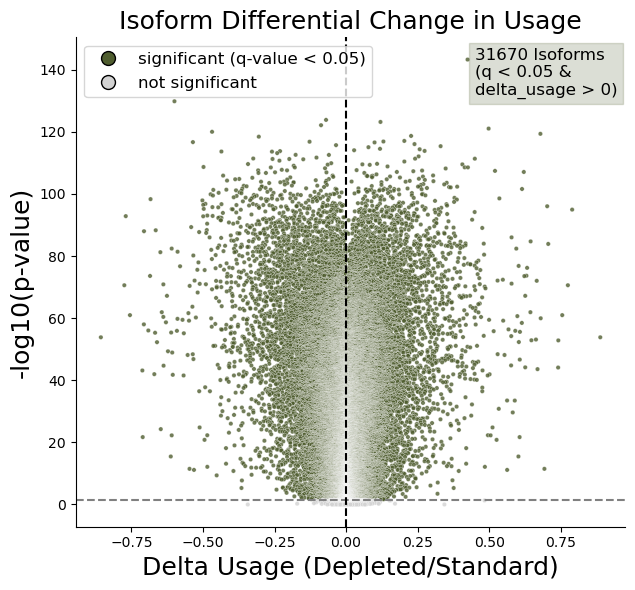

In [10]:
#plot a volcano plot of log2FoldChange vs -log10(pvalue)
fig, ax = plt.subplots(figsize=(6.5, 6))
sns.scatterplot(
    data=data,
    x='delta_usage',
    y='-log10(pvalue)',
    hue='significant',
    alpha=0.8,
    s=10,
    palette={'significant': '#4F5D2F', 'not significant': 'lightgrey'},
    ax=ax
)

#add a text box in '#4F5D2F' that counts the number of significant isoforms (q-value < 0.05 with delta_usage > 0)
significant_count = data[(data['significant'] == 'significant') & (data['delta_usage'] > 0)].shape[0]
ax.text(0.45, 132, f'{significant_count} Isoforms\n(q < 0.05 & \ndelta_usage > 0)',
        fontsize=12, color='black', bbox=dict(facecolor='#4F5D2F', alpha=0.2, edgecolor='#4F5D2F'))

ax.axhline(-np.log10(0.05), color='grey', linestyle='--')
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel('Delta Usage (Depleted/Standard)', fontsize=18)
ax.set_ylabel('-log10(p-value)', fontsize=18)
ax.set_title('Isoform Differential Change in Usage', fontsize=18)
legend_elems = [
    Line2D([0],[0], marker='o', linestyle='None', markersize=10,
           markerfacecolor='#4F5D2F', markeredgecolor='black', label='significant (q-value < 0.05)'),
    Line2D([0],[0], marker='o', linestyle='None', markersize=10,
           markerfacecolor='lightgrey', markeredgecolor='black', label='not significant'),
]
ax.legend(handles=legend_elems, loc='upper left', fontsize=12)
#remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('applied_depletion_gregor_n100/paper_figures/saturn_Volcano_plot_isoforms.png', dpi=300)
plt.show()

In [11]:
#for each Gene name, take the absolute value of delta_usage and sum them up to get a gene-level delta_usage
gene_data = data.copy()
gene_data['abs_delta_usage'] = gene_data['delta_usage'].abs()
gene_data = gene_data.groupby('Gene name')['abs_delta_usage'].sum().reset_index()
gene_data = gene_data.sort_values(by='abs_delta_usage', ascending=False)
gene_data.head(20)

,Gene name,abs_delta_usage
130,ACSL1,1.660723
9835,MORC3,1.585448
1919,CLEC4A,1.549634
9475,MAPRE2,1.514523
820,ATP5F1C,1.509930
8075,HLA-A,1.484262
10800,PAFAH1B1,1.446927
556,APPAT,1.438880
11438,PPIB,1.430997
14106,TMEM176B,1.428509


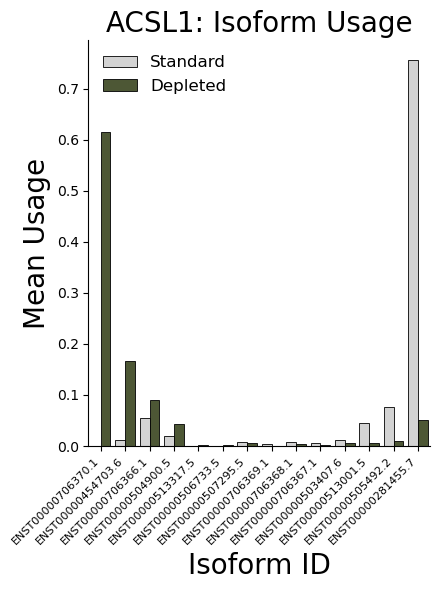

In [237]:
check = data[data['Gene name']=='ACSL1']
check = check.sort_values(by='delta_usage', ascending=False)

long = (check
        .melt(id_vars='isoform_id',
              value_vars=['mean_usage_WM', 'mean_usage_D'],
              var_name='condition', value_name='mean_usage')
        .replace({'condition': {
            'mean_usage_WM': 'Standard',
            'mean_usage_D': 'Depleted'
        }}))

palette = {'Standard': 'lightgrey', 'Depleted': '#4F5D2F'}

plt.figure(figsize=(4.5, 6))
ax = sns.barplot(
    data=long,
    x='isoform_id',
    y='mean_usage',
    hue='condition',
    palette=palette,
    dodge=True,
    edgecolor='black',
    linewidth=0.6,
)

# styling
ax.set_ylabel('Mean Usage', fontsize=20)
ax.set_xlabel('Isoform ID', fontsize=20)
ax.set_title('ACSL1: Isoform Usage', fontsize=20)
ax.legend(fontsize=12, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('applied_depletion_gregor_n100/paper_figures/ACSL1_isoform_usage_comparison.png', dpi=300)
plt.show()

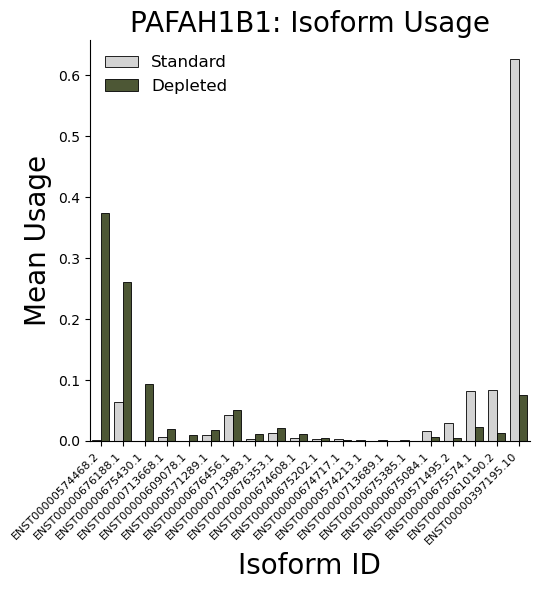

In [238]:
check = data[data['Gene name']=='PAFAH1B1']
check = check.sort_values(by='delta_usage', ascending=False)

long = (check
        .melt(id_vars='isoform_id',
              value_vars=['mean_usage_WM', 'mean_usage_D'],
              var_name='condition', value_name='mean_usage')
        .replace({'condition': {
            'mean_usage_WM': 'Standard',
            'mean_usage_D': 'Depleted'
        }}))

palette = {'Standard': 'lightgrey', 'Depleted': '#4F5D2F'}

plt.figure(figsize=(5.5, 6))
ax = sns.barplot(
    data=long,
    x='isoform_id',
    y='mean_usage',
    hue='condition',
    palette=palette,
    dodge=True,
    edgecolor='black',
    linewidth=0.6,
)

# styling
ax.set_ylabel('Mean Usage', fontsize=20)
ax.set_xlabel('Isoform ID', fontsize=20)
ax.set_title('PAFAH1B1: Isoform Usage', fontsize=20)
ax.legend(fontsize=12, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('applied_depletion_gregor_n100/paper_figures/PAFAH1B1_isoform_usage_comparison.png', dpi=300)
plt.show()

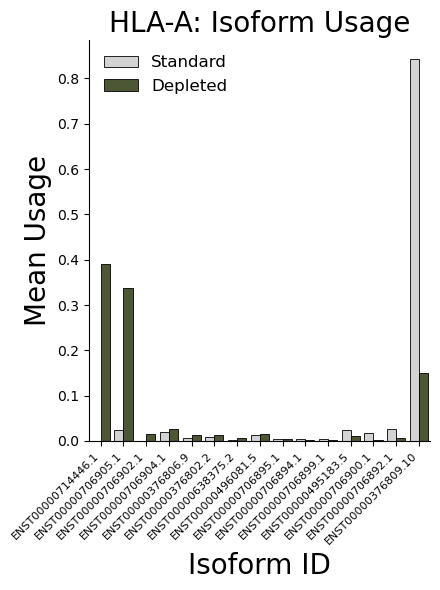

In [239]:
check = data[data['Gene name']=='HLA-A']
check = check.sort_values(by='delta_usage', ascending=False)

long = (check
        .melt(id_vars='isoform_id',
              value_vars=['mean_usage_WM', 'mean_usage_D'],
              var_name='condition', value_name='mean_usage')
        .replace({'condition': {
            'mean_usage_WM': 'Standard',
            'mean_usage_D': 'Depleted'
        }}))

palette = {'Standard': 'lightgrey', 'Depleted': '#4F5D2F'}

plt.figure(figsize=(4.5, 6))
ax = sns.barplot(
    data=long,
    x='isoform_id',
    y='mean_usage',
    hue='condition',
    palette=palette,
    dodge=True,
    edgecolor='black',
    linewidth=0.6,
)

# styling
ax.set_ylabel('Mean Usage', fontsize=20)
ax.set_xlabel('Isoform ID', fontsize=20)
ax.set_title('HLA-A: Isoform Usage', fontsize=20)
ax.legend(fontsize=12, frameon=False)
#remove spine top and right
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('applied_depletion_gregor_n100/paper_figures/HLA-A_isoform_usage_comparison.png', dpi=300)
plt.show()

Leafcutter - Intron clusters 
-

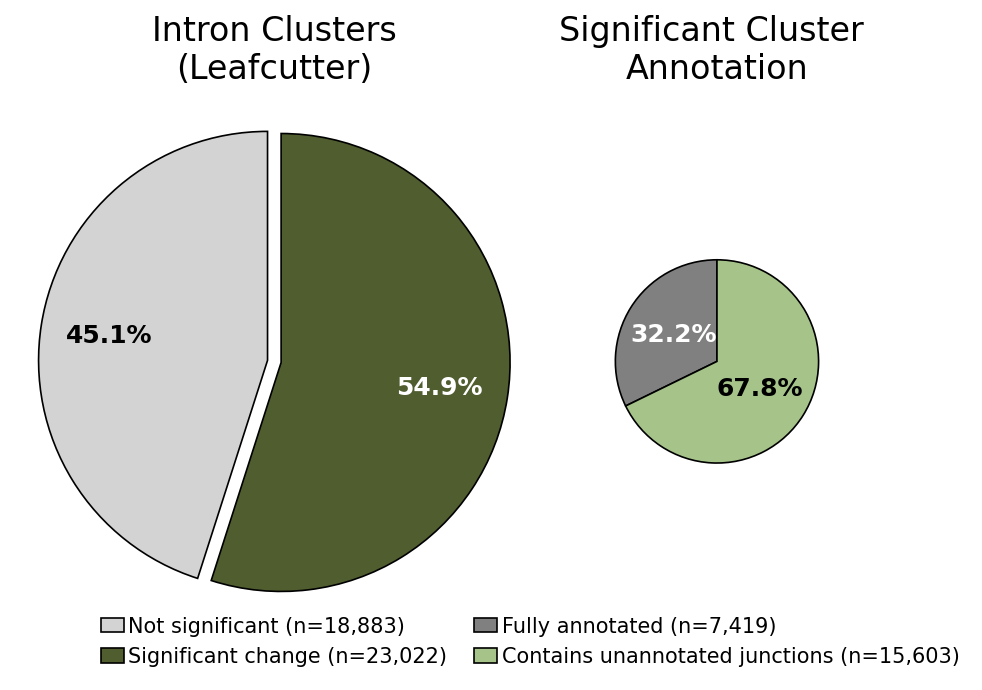

In [13]:
# outputs from leafcutter summary statistics
# --- Inputs ---
results = [41905, 23022, 7419, 15603]
# [All, Significant, Fully annotated, Contains unannotated]
total, significant, fully, unannot = results

# Sanity check
if fully + unannot != significant:
    print(f"Warning: fully ({fully}) + unannot ({unannot}) != significant ({significant})")

# Pie 1: Significant vs Not significant
sizes1 = [total - significant, significant]
labels1 = [
    f"Not significant (n={total - significant:,})",
    f"Significant change (n={significant:,})"
]
colors1 = ['lightgrey', '#4F5D2F']   # grey, green
explode1 = [0.00, 0.06]              # lift the significant slice

# Pie 2: Significant breakdown
sizes2 = [fully, unannot]
labels2 = [
    f"Fully annotated (n={fully:,})",
    f"Contains unannotated junctions (n={unannot:,})"
]
colors2 = ['grey', '#A6C48A']    

# --- Figure & axes ---
fig = plt.figure(figsize=(7, 6), dpi=150)
ax1 = plt.subplot2grid((1, 3), (0, 0), colspan=2)  # left
ax2 = plt.subplot2grid((1, 3), (0, 2))             # right

# ------- PIE 1 (normal pie) -------
wedges1, texts1, autotexts1 = ax1.pie(
    sizes1,
    labels=None,
    colors=colors1,
    explode=explode1,
    startangle=90,
    autopct='%1.1f%%',
    pctdistance=0.70,
    wedgeprops=dict(edgecolor='black', linewidth=0.8)
)
ax1.set_title("Intron Clusters\n(Leafcutter)", fontsize=16,)
ax1.axis('equal')

# Contrast for % labels
for w, a in zip(wedges1, autotexts1):
    face = w.get_facecolor()[:3]
    a.set_color('white' if face == tuple(plt.matplotlib.colors.to_rgb('#4F5D2F')) else 'black')
    a.set_fontsize(12)
    a.set_fontweight('bold')

# Legend under Pie 1
ax1.legend(
    handles=wedges1,
    labels=labels1,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=1,
    frameon=False,
    handlelength=1.1,
    handletextpad=0.2
)

# ------- PIE 2 (normal pie) -------
wedges2, texts2, autotexts2 = ax2.pie(
    sizes2,
    labels=None,
    colors=colors2,
    startangle=90,
    autopct='%1.1f%%',
    pctdistance=0.50,
    wedgeprops=dict(edgecolor='black', linewidth=0.8)
)
ax2.set_title("Significant Cluster \nAnnotation", fontsize=16, )
ax2.axis('equal')

for w, a in zip(wedges2, autotexts2):
    face = w.get_facecolor()[:3]
    a.set_color('white' if face == tuple(plt.matplotlib.colors.to_rgb('grey')) else 'black')
    a.set_fontsize(12)
    a.set_fontweight('bold')

# Legend under Pie 2
ax2.legend(
    handles=wedges2,
    labels=labels2,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=1,
    frameon=False,
    handlelength=1.1,
    handletextpad=0.2
)

# Layout & save
plt.subplots_adjust(top=0.7, bottom=0.1, wspace=0.32)
plt.savefig('applied_depletion_gregor_n100/paper_figures/leafcutter_intron_clusters_pie_chart.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [14]:
meta = pd.read_csv("applied_depletion_gregor_n100/leafcutter/intron_gene_overlap.tsv", sep="\t", header=None)
meta['intron'] = meta[3]
meta['gene'] = meta[9].str.split(';').str[1]
meta_genes = (
    meta.groupby('intron')['gene']
        .apply(lambda g: ','.join(sorted(set(g))))  
        .reset_index(name='genes_combined')
)
meta_unique = meta.drop(columns=['gene']).drop_duplicates('intron') \
                  .merge(meta_genes, on='intron', how='left')
meta_unique.set_index('intron', inplace=True)
meta_unique

,0,1,2,3,4,5,6,7,8,9,10,11,genes_combined
intron,,,,,,,,,,,,,
chr1:182746:183114:clu_16299_+,chr1,182745,183114,chr1:182746:183114:clu_16299_+,0,+,chr1,180930,184937,ENSG00000308415.1;DDX11L2,0,+,"DDX11L17,DDX11L2"
chr1:182746:183132:clu_16299_+,chr1,182745,183132,chr1:182746:183132:clu_16299_+,0,+,chr1,180930,184937,ENSG00000308415.1;DDX11L2,0,+,"DDX11L17,DDX11L2"
chr1:182746:183165:clu_16299_+,chr1,182745,183165,chr1:182746:183165:clu_16299_+,0,+,chr1,180930,184937,ENSG00000308415.1;DDX11L2,0,+,"DDX11L17,DDX11L2"
chr1:183216:183740:clu_16300_+,chr1,183215,183740,chr1:183216:183740:clu_16300_+,0,+,chr1,180930,184937,ENSG00000308415.1;DDX11L2,0,+,"DDX11L17,DDX11L2"
chr1:183216:183922:clu_16300_+,chr1,183215,183922,chr1:183216:183922:clu_16300_+,0,+,chr1,180930,184937,ENSG00000308415.1;DDX11L2,0,+,"DDX11L17,DDX11L2"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrY:20524440:20553299:clu_43009_-,chrY,20524439,20553299,chrY:20524440:20553299:clu_43009_-,0,-,chrY,20464915,20575519,ENSG00000229236.4;TTTY10,0,-,TTTY10
chrY:20524440:20575106:clu_43009_-,chrY,20524439,20575106,chrY:20524440:20575106:clu_43009_-,0,-,chrY,20570221,20570519,ENSG00000277438.1;KDM5DP1,0,-,"KDM5DP1,TTTY10"
chrY:20527286:20575106:clu_43009_-,chrY,20527285,20575106,chrY:20527286:20575106:clu_43009_-,0,-,chrY,20570221,20570519,ENSG00000277438.1;KDM5DP1,0,-,"KDM5DP1,TTTY10"


In [15]:
data = pd.read_csv("applied_depletion_gregor_n100/leafcutter/leafcutter_ds_effect_sizes.txt", sep="\t")
data['chr']=data['intron'].str.split(':').str[0]
data['cluster_raw']=data['intron'].str.split(':').str[3]
data['cluster'] = data['chr'] + ':' + data['cluster_raw']
data.drop(columns=['cluster_raw'], inplace=True)
data['start'] = data['intron'].str.split(':').str[1].astype(int)
data['end'] = data['intron'].str.split(':').str[2].astype(int)
data.set_index('intron', inplace=True)
data['genes_combined'] = data.index.map(meta_unique['genes_combined'])
data = data.sort_values(by='deltapsi', ascending=False)
data.head(50)

,logef,WM,D,deltapsi,chr,cluster,start,end,genes_combined
intron,,,,,,,,,
chr7:30593771:30594711:clu_44814_-,3.289143,0.045295,0.868244,0.822948,chr7,chr7:clu_44814_-,30593771,30594711,GARS1-DT
chrX:12906709:12910151:clu_18905_+,3.461077,0.101200,0.864591,0.763391,chrX,chrX:clu_18905_+,12906709,12910151,TLR8
chrX:13655373:13662501:clu_18907_+,2.898782,0.099197,0.764179,0.664983,chrX,chrX:clu_18907_+,13655373,13662501,TCEANC
chr1:150731120:150732908:clu_35972_-,2.832067,0.322201,0.970813,0.648613,chr1,chr1:clu_35972_-,150731120,150732908,CTSS
chr20:44663553:44671639:clu_26198_-,2.576067,0.177377,0.812848,0.635471,chr20,chr20:clu_26198_-,44663553,44671639,KCNK15-AS1
chr19:52614797:52618936:clu_10020_-,1.971844,0.238956,0.858087,0.619132,chr19,chr19:clu_10020_-,52614797,52618936,"ENSG00000269825,ZNF83"
chr9:83915678:83921371:clu_12311_-,3.385053,0.317046,0.911306,0.594259,chr9,chr9:clu_12311_-,83915678,83921371,"ENSG00000309071,KIF27"
chr19:51936235:51940209:clu_34177_+,2.331086,0.147720,0.732874,0.585154,chr19,chr19:clu_34177_+,51936235,51940209,ZNF613
chr11:17334480:17337348:clu_48318_+,1.780367,0.243389,0.822958,0.579569,chr11,chr11:clu_48318_+,17334480,17337348,NUCB2
